### Human evaluation study

This notebook analyses the result of the human evaluation exports in `eval/`. It answers two questions:

1. **Human study:** Across the same participant and image, how do BAD and Prompt Only outputs differ in perceived coherence, modality alignment, and usefulness?
2. **Proxy agreement:** Across the 10 evaluated outputs, how closely do DeepSeek and CLIP scores follow mean human judgments?

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_eval_dir():
    for base in (Path.cwd(), *Path.cwd().parents):
        candidate = base / "eval"
        if (candidate / "brandbit-shared-study-ratings-2026-09-25.csv").is_file():
            return candidate
    raise FileNotFoundError("Open this notebook from the repository or eval/notebook directory.")

EVAL = find_eval_dir()
RATINGS_FILE = EVAL / "brandbit-shared-study-ratings-2026-09-25.csv"
SCORES_FILE = EVAL / "comparison" / "shared_judge_clip" / "shared_judge_clip_20260927T061210Z.csv"
print("Reading exports from:", EVAL)

Reading exports from: d:\CM3070_Brandbit\eval


In [5]:
ratings = pd.read_csv(RATINGS_FILE, dtype={"Participant ID": "string", "Execution ID": "string"})
scores = pd.read_csv(SCORES_FILE, dtype={"Execution ID": "string"})

MODE = "Process (BAD / Prompt Only)"
PID = "Participant ID"
EXEC = "Execution ID"
rating_columns = {
    "Descriptor accuracy": "Descriptor accuracy (1-5)",
    "Brand coherence": "Brand coherence (1-5)",
    "Fragrance alignment": "Fragrance alignment (1-5)",
    "Music alignment": "Music alignment (1-5)",
    "Cross-modal congruence": "Cross-modal congruence (1-5)",
    "Creativity": "Creativity (1-5)",
    "Ideation usefulness": "Ideation usefulness (1-5)",
    "Overall quality": "Overall quality (1-5)",
}
for col in rating_columns.values():
    ratings[col] = pd.to_numeric(ratings[col], errors="coerce")
ratings["image_id"] = ratings[EXEC].str.replace(r"\s*\((BAD|Prompt Only)\)$", "", regex=True)
scores["image_id"] = scores[EXEC].str.replace(r"\s*\((BAD|Prompt Only)\)$", "", regex=True)

assert len(ratings) == 150, f"Expected 150 ratings; found {len(ratings)}"
assert ratings[PID].nunique() == 15
assert ratings["image_id"].nunique() == 5
assert set(ratings[MODE]) == {"BAD", "Prompt Only"}
assert len(scores) == 10 and scores[EXEC].is_unique
assert not ratings.duplicated([PID, "image_id", MODE]).any(), "Duplicate participant/image/mode rating"
assert (ratings.groupby([PID, "image_id"])[MODE].nunique() == 2).all(), "Incomplete mode pair"
assert ratings[list(rating_columns.values())].notna().all().all(), "Missing Likert rating"
assert ratings[list(rating_columns.values())].apply(lambda s: s.between(1, 5)).all().all(), "Rating outside 1–5"
assert set(ratings[EXEC]) == set(scores[EXEC]), "Automated-score export does not match rated outputs"

print(f"{ratings[PID].nunique()} participants; {ratings['image_id'].nunique()} images; {len(ratings)} ratings; {len(ratings)//2} matched pairs")
display(ratings.groupby(MODE).size().rename("rating_rows").to_frame())
display(ratings.groupby([PID, "image_id"]).size().value_counts().rename("pairs_per_participant_image").to_frame())

15 participants; 5 images; 150 ratings; 75 matched pairs


,rating_rows
Process (BAD / Prompt Only),
BAD,75
Prompt Only,75


,pairs_per_participant_image
2,75


,BAD mean,Prompt Only mean,Mean paired difference,95% bootstrap low,95% bootstrap high,Participants favoring BAD,Participants favoring Prompt Only,Ties
Measure,,,,,,,,
Descriptor accuracy,4.440,4.400,0.040,-0.080,0.173,6,5,4
Brand coherence,4.373,4.267,0.107,-0.133,0.387,7,4,4
Fragrance alignment,4.253,4.147,0.107,-0.040,0.280,5,3,7
Music alignment,4.360,4.107,0.253,0.053,0.507,8,2,5
Cross-modal congruence,4.280,4.160,0.120,-0.053,0.293,8,3,4
Creativity,4.400,4.280,0.120,-0.067,0.320,7,3,5
Ideation usefulness,4.360,4.400,-0.040,-0.160,0.120,3,8,4
Overall quality,4.440,4.347,0.093,-0.067,0.280,4,2,9


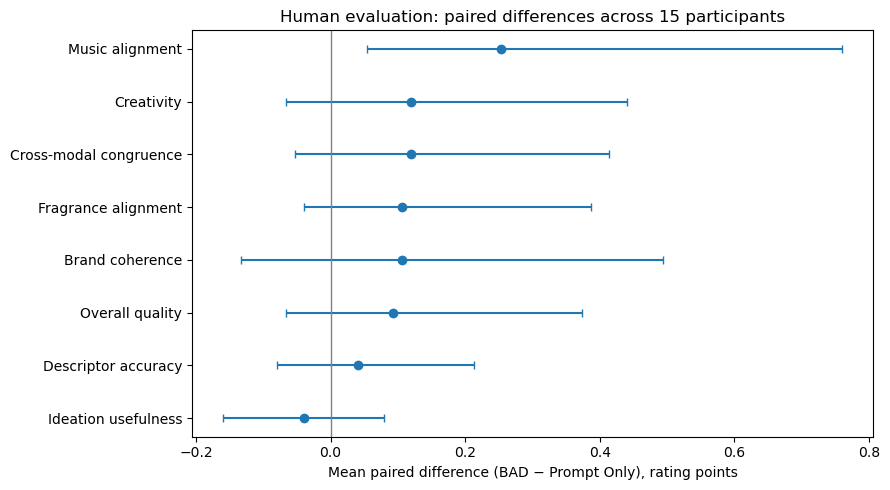

In [6]:
paired = ratings.pivot(index=[PID, "image_id"], columns=MODE, values=list(rating_columns.values()))
paired.columns = [f"{measure} | {mode}" for measure, mode in paired.columns]
paired = paired.reset_index()
for label, col in rating_columns.items():
    paired[f"{label} difference"] = paired[f"{col} | BAD"] - paired[f"{col} | Prompt Only"]

rng = np.random.default_rng(20260925)
rows = []
for label, col in rating_columns.items():
    person_diffs = paired.groupby(PID)[f"{label} difference"].mean().to_numpy(dtype=float)
    boot = rng.choice(person_diffs, size=(10000, len(person_diffs)), replace=True).mean(axis=1)
    rows.append({
        "Measure": label,
        "BAD mean": ratings.loc[ratings[MODE] == "BAD", col].mean(),
        "Prompt Only mean": ratings.loc[ratings[MODE] == "Prompt Only", col].mean(),
        "Mean paired difference": person_diffs.mean(),
        "95% bootstrap low": np.quantile(boot, 0.025),
        "95% bootstrap high": np.quantile(boot, 0.975),
        "Participants favoring BAD": int((person_diffs > 0).sum()),
        "Participants favoring Prompt Only": int((person_diffs < 0).sum()),
        "Ties": int((person_diffs == 0).sum()),
    })
human_summary = pd.DataFrame(rows).set_index("Measure")
display(human_summary.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
plot = human_summary.sort_values("Mean paired difference")
x = plot["Mean paired difference"]
ax.errorbar(x, plot.index, xerr=[x - plot["95% bootstrap low"], plot["95% bootstrap high"]], fmt="o", capsize=3)
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Mean paired difference (BAD − Prompt Only), rating points")
ax.set_title("Human evaluation: paired differences across 15 participants")
plt.tight_layout()
plt.show()

,Cross-modal congruence,Fragrance alignment,Music alignment,Brand coherence
image_id,,,,
Axioo_Pongo_001,-0.067,0.200,0.267,-0.267
BatikKeris_001,0.600,0.333,0.667,-0.067
Indomie_001,-0.200,0.067,-0.400,0.067
Singa_Watch_001,-0.067,-0.067,0.400,0.467
Tulola_Jewellery_001,0.333,0.000,0.333,0.333


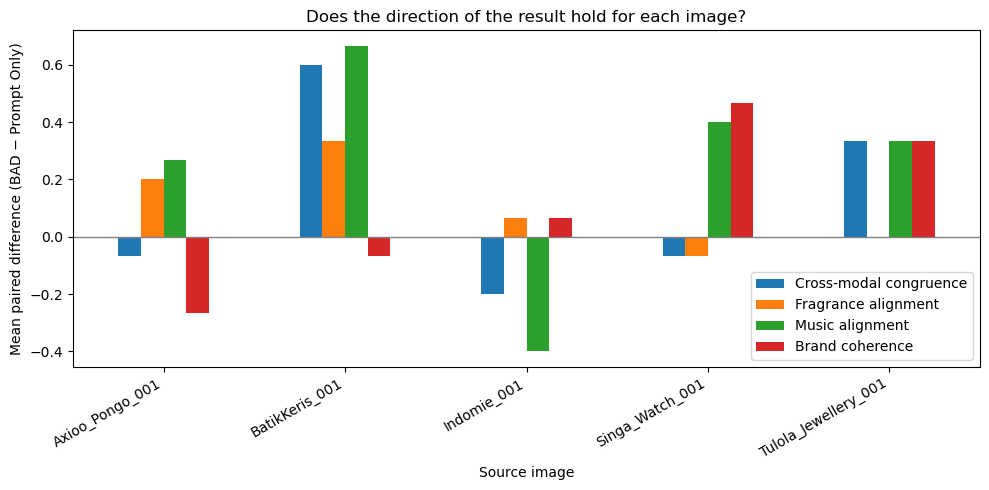

In [7]:
key_measures = ["Cross-modal congruence", "Fragrance alignment", "Music alignment", "Brand coherence"]
by_image = pd.DataFrame({
    label: paired.groupby("image_id")[f"{label} difference"].mean()
    for label in key_measures
})
display(by_image.round(3))
ax = by_image.plot.bar(figsize=(10, 5))
ax.axhline(0, color="gray", linewidth=1)
ax.set_ylabel("Mean paired difference (BAD − Prompt Only)")
ax.set_xlabel("Source image")
ax.set_title("Does the direction of the result hold for each image?")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Human judgments versus automated proxies

,Execution ID,Process (BAD / Prompt Only),Cross-modal congruence (1-5),DeepSeek fragrance score (1-5),DeepSeek music score (1-5),CLIP image-fragrance,CLIP image-music
0,Axioo_Pongo_001 (BAD),BAD,4.200,4,5,0.351,0.217
1,Axioo_Pongo_001 (Prompt Only),Prompt Only,4.267,4,5,0.366,0.253
2,BatikKeris_001 (BAD),BAD,4.400,4,5,0.414,0.456
3,BatikKeris_001 (Prompt Only),Prompt Only,3.800,4,5,0.369,0.499
4,Indomie_001 (BAD),BAD,4.333,4,5,0.404,0.588
5,Indomie_001 (Prompt Only),Prompt Only,4.533,4,5,0.454,0.415
6,Singa_Watch_001 (BAD),BAD,3.933,4,5,0.313,0.089
7,Singa_Watch_001 (Prompt Only),Prompt Only,4.000,4,4,0.308,0.345
8,Tulola_Jewellery_001 (BAD),BAD,4.533,4,5,0.560,0.381
9,Tulola_Jewellery_001 (Prompt Only),Prompt Only,4.200,4,5,0.594,0.436


,Human measure,Automated measure,Distinct outputs,Spearman rho,Interpretation
0,Fragrance alignment,DeepSeek fragrance,10,NaN,undefined: one score is constant
1,Music alignment,DeepSeek music,10,0.524,exploratory
2,Fragrance alignment,CLIP fragrance,10,0.802,exploratory
3,Music alignment,CLIP music,10,-0.018,exploratory


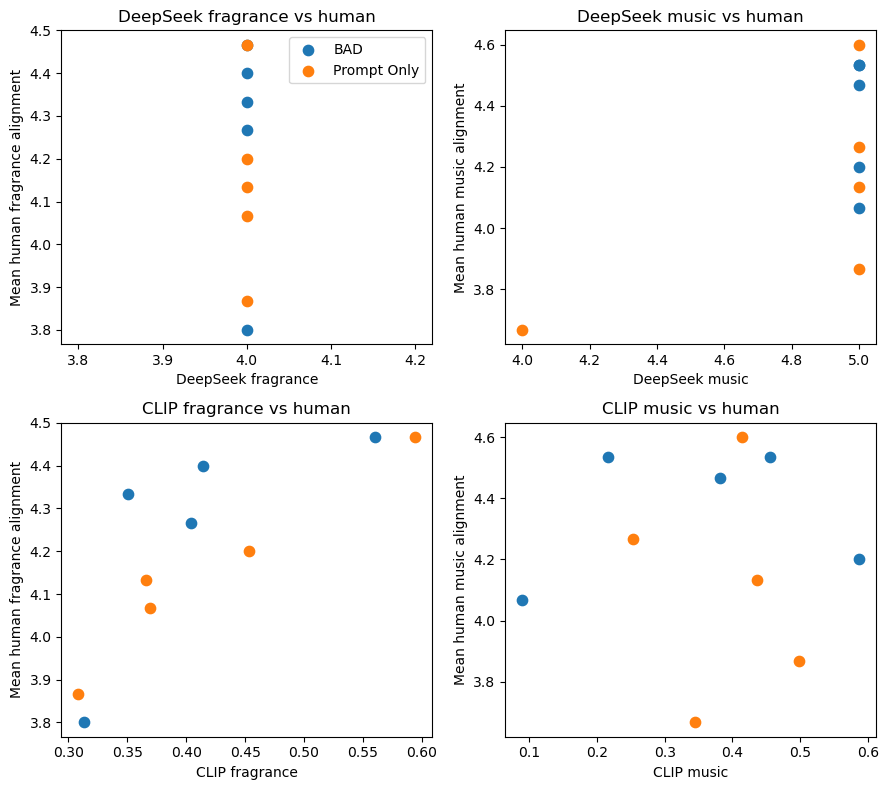

In [8]:
auto_numeric = {
    "DeepSeek fragrance": "DeepSeek fragrance score (1-5)",
    "DeepSeek music": "DeepSeek music score (1-5)",
    "CLIP fragrance": "CLIP image-fragrance",
    "CLIP music": "CLIP image-music",
}
for col in auto_numeric.values():
    scores[col] = pd.to_numeric(scores[col], errors="coerce")
human_by_output = ratings.groupby(EXEC)[list(rating_columns.values())].mean().reset_index()
joined = human_by_output.merge(
    scores[[EXEC, MODE, "image_id", *auto_numeric.values()]],
    on=EXEC, how="left", validate="one_to_one", indicator=True
)
assert joined["_merge"].eq("both").all()
display(joined[[EXEC, MODE, rating_columns["Cross-modal congruence"], *auto_numeric.values()]].round(3))

proxy_pairs = [
    ("Fragrance alignment", "DeepSeek fragrance"),
    ("Music alignment", "DeepSeek music"),
    ("Fragrance alignment", "CLIP fragrance"),
    ("Music alignment", "CLIP music"),
]
proxy_rows = []
for human_label, proxy_label in proxy_pairs:
    human_col, proxy_col = rating_columns[human_label], auto_numeric[proxy_label]
    valid = joined[[human_col, proxy_col]].dropna()
    variable = valid[human_col].nunique() > 1 and valid[proxy_col].nunique() > 1
    proxy_rows.append({
        "Human measure": human_label,
        "Automated measure": proxy_label,
        "Distinct outputs": len(valid),
        "Spearman rho": valid[human_col].corr(valid[proxy_col], method="spearman") if variable else np.nan,
        "Interpretation": "exploratory" if variable else "undefined: one score is constant",
    })
proxy_summary = pd.DataFrame(proxy_rows)
display(proxy_summary.round(3))

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (human_label, proxy_label) in zip(axes.flat, proxy_pairs):
    human_col, proxy_col = rating_columns[human_label], auto_numeric[proxy_label]
    for mode, group in joined.groupby(MODE):
        ax.scatter(group[proxy_col], group[human_col], label=mode, s=55)
    ax.set(xlabel=proxy_label, ylabel=f"Mean human {human_label.lower()}", title=f"{proxy_label} vs human")
axes[0, 0].legend()
plt.tight_layout()
plt.show()

In [9]:
comments = ratings.loc[ratings["Comments"].fillna("").str.strip().ne(""), [EXEC, MODE, "Comments"]].copy()
print(f"Non-empty comments: {len(comments)} of {len(ratings)} ratings")
display(comments.head(10))

Non-empty comments: 10 of 150 ratings


,Execution ID,Process (BAD / Prompt Only),Comments
0,Indomie_001 (Prompt Only),Prompt Only,The music was my fav I can see the brand ident...
15,Indomie_001 (BAD),BAD,The descriptions in the decks for fragrance co...
24,Indomie_001 (BAD),BAD,"this music is good, i like"
30,Tulola_Jewellery_001 (Prompt Only),Prompt Only,This one I understood the vision for the image...
45,Tulola_Jewellery_001 (BAD),BAD,The music in the other version fitted more for...
98,Singa_Watch_001 (BAD),BAD,It feels luxurious but feels like lack one poi...
126,BatikKeris_001 (BAD),BAD,The song fits the object that is presented
129,BatikKeris_001 (BAD),BAD,Cool man the sound feel luxurious and local li...
143,BatikKeris_001 (Prompt Only),Prompt Only,Mayble the BAD one feels more luxurious and lo...
148,BatikKeris_001 (Prompt Only),Prompt Only,quite abstract
